# CI/CD Pipline for DDOS detection

1. Feature Engineering
- Raw input data stored in S3 is processed to clean, normalize, and encode relevant features.
- Using a RandomForestClassifier, the top 10 most important features are selected.
- The transformed dataset is saved back to S3 in CSV format for use in subsequent steps.

2. Feature Store Ingestion
- The cleaned and engineered data is ingested into a SageMaker Feature Store by creating a new Feature Group.

3. Data Splitting
The dataset is partitioned into training, validation, test and batch sets. These splits are stored in S3 and serve as inputs for model training and evaluation.

4. Model Training
- A binary classification model is trained using the selected features to detect DDoS attacks.
- The model artifact is saved to S3 for batch inference.

5. Batch Inference (Transform Step)
- The trained model is applied to the batch dataset using Batch Transform. This step generates prediction outputs which are then used for evaluation.

6. Batch prediction report
- The predicted results are compared against the ground truth to compute accuracy, precision, recall, and F1-score. The evaluation results are saved to S3 and used to determine the pipline is succeeded or failed.

7. Condition Step
- A Accuracy based condition is defined to check whether the model meets a defined threshold for the batch data. 

In [1]:
!pip install sagemaker

In [2]:
# import packages
import boto3
import sagemaker
from sagemaker.workflow.pipeline import Pipeline
from sagemaker.workflow.steps import ProcessingStep, TrainingStep, TransformStep
from sagemaker.workflow.parameters import ParameterInteger
from sagemaker.workflow.parameters import ParameterFloat
from sagemaker.workflow.parameters import ParameterString
from sagemaker.processing import ProcessingInput, ProcessingOutput
from sagemaker.sklearn.processing import SKLearnProcessor, ScriptProcessor
from sagemaker.workflow.pipeline_context import PipelineSession

import sys

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## 1. Setup

In [3]:
# Create a directory for python scripts
!mkdir -p code

In [4]:
framework_version = "1.2-1"

In [5]:
# SageMaker session and role
sagemaker_session = sagemaker.session.Session()
pipeline_session = PipelineSession()
region = sagemaker_session.boto_region_name
role = sagemaker.get_execution_role()
bucket = sagemaker_session.default_bucket()

In [6]:
# define paths
s3_raw_data_prefix = 'final_project/data'
data_filename= 'DDoS-Friday-no-metadata.parquet'
s3_engineered_prefix = 'final_project/feature_engineer'
engineered_filename = 'engineered_features.csv'
input_uri = f"s3://{bucket}/{s3_raw_data_prefix}"

## 2. Create Steps

### 2.1 Feature engineering 

#### 2.1.1 Pipeline Parameters

In [7]:
input_data_uri = f"s3://{bucket}/{s3_raw_data_prefix}/{data_filename}"
output_data_uri = f"s3://{bucket}/{s3_engineered_prefix}"

In [8]:
# Pipeline Parameters
input_data = ParameterString(name="InputData", default_value=input_data_uri)
output_data = ParameterString(name="OutputData", default_value=output_data_uri)

#### 2.1.2. Processor setup

In [9]:
sklearn_processor = SKLearnProcessor(
    framework_version=framework_version,
    role=role,
    instance_type="ml.m5.large",
    instance_count=1,
    base_job_name="DDoS-Detection-Pipeline-processor",
    sagemaker_session=pipeline_session
)

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


#### 2.1.3. Step script

In [10]:
%%writefile code/feature_engineering.py
print("code/feature_engineering.py")
import pandas as pd
import numpy as np
import boto3
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import sys
import os
import io
import uuid
import time
from time import gmtime, strftime, sleep

if __name__ == "__main__":
    base_dir = "/opt/ml/processing"
    df = pd.read_parquet(f'{base_dir}/input/DDoS-Friday-no-metadata.parquet')
    print(df.shape)
    
    # shuffel the data
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(df['label'].value_counts())
    
    # Drop columns with all NaNs
    df_cleaned = df.dropna(axis=1, thresh=1)
    
    # Binary label encoding
    df_cleaned['label'] = df_cleaned['label'].apply(lambda x: 0 if str(x).lower() == 'benign' else 1)
    print(df_cleaned.shape)
    
    # Normalize numeric features
    features = df.drop('label', axis=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    X_scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
    X_scaled_df['label'] = df['label']
    
    # Feature selection using Random Forest
    X = X_scaled_df.drop('label', axis=1)
    y = X_scaled_df['label']
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y)
    
    # Select top 10 features
    importances = clf.feature_importances_
    top_features = X.columns[np.argsort(importances)[::-1][:10]]
    
    # df_final dataframe with final selected features will be stored. df_final can be used by the model to train/validate and test.
    df_final = df_cleaned[top_features.tolist() + ['label']]
    
    print(top_features)
    
    current_time_sec = int(round(time.time()))
    
    # Move target column to front
    target_col = "label"
    df_final = df_final[[target_col] + [col for col in df_final.columns if col != target_col]]
    
    # Add required metadata columns
    record_identifier_feature_name = "record_id"
    df_final[record_identifier_feature_name] = [str(uuid.uuid4()) for _ in range(len(df_final))]
    event_time_feature_name = 'event_time'
    df_final[event_time_feature_name] = pd.Series([current_time_sec] * len(df_final), dtype="float64")
    pd.DataFrame(df_final).to_csv(f"{base_dir}/feature_engineered/engineered_features.csv", header=True, index=False)   

Overwriting code/feature_engineering.py


In [11]:
input_data_uri

's3://sagemaker-us-east-1-249645693565/final_project/data/DDoS-Friday-no-metadata.parquet'

#### 2.1.4. Processing Step 

In [12]:
step_feature_engineering_process = ProcessingStep(
    name="FeatureEngineering",
    processor=sklearn_processor,
    inputs=[ProcessingInput(source=input_data_uri, destination="/opt/ml/processing/input")],
    outputs=[ProcessingOutput(output_name="feature_engineered", source="/opt/ml/processing/feature_engineered",
                              destination = output_data_uri)],
    code= "code/feature_engineering.py",
    
)

### 2.2 Feature store ingestion

#### 2.2.1. Pipeline Parameters

In [13]:
#input_feature_uri = f"s3://{bucket}/{s3_engineered_prefix}/{engineered_filename}"
input_feature_uri = step_feature_engineering_process.properties.ProcessingOutputConfig.Outputs["feature_engineered"].S3Output.S3Uri

In [14]:
input_feature_uri

{'_step': <sagemaker.workflow.steps.ProcessingStep object at 0x7f20d1265c70>, 'step_name': 'FeatureEngineering', 'path': "ProcessingOutputConfig.Outputs['feature_engineered'].S3Output.S3Uri", '_shape_names': ['S3Uri'], '__str__': 'S3Uri'}

In [15]:
from time import strftime, gmtime
group_name = f"feature-group-ddos-detection-{strftime('%d-%H-%M-%S', gmtime())}"
print('feature_group_name :', group_name)
feature_group_name = ParameterString(name="FeatureGroupName", default_value=group_name)
sagemaker_role = role

feature_group_name : feature-group-ddos-detection-21-03-31-45


#### 2.2.2. Step Script

In [16]:
%%writefile 'code/feature_store_ingest.py'
import argparse
import boto3
import sagemaker
from sagemaker import Session
from sagemaker.feature_store.feature_group import FeatureGroup
import time
from time import gmtime, strftime, sleep
import pandas as pd

def wait_for_feature_group_creation_complete(feature_group):
    status = feature_group.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print("Waiting for Feature Group Creation")
        time.sleep(5)
        status = feature_group.describe().get("FeatureGroupStatus")
    if status != "Created":
        raise RuntimeError(f"Failed to create feature group {feature_group.name}")
    print(f"FeatureGroup {feature_group.name} successfully created.")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--feature-group-name", type=str, required=True)
    parser.add_argument("--sagemaker-role", type=str, required=True)
    args = parser.parse_args()
    intrusion_feature_group_name = args.feature_group_name
    role = args.sagemaker_role
    print(intrusion_feature_group_name, role)
    base_dir = "/opt/ml/processing"
    # intrusion_feature_group_name = "feature-group-DDOS-detection" + strftime("%d-%H-%M-%S", gmtime())
    # Create boto3 session
    boto_session = boto3.Session(region_name="us-east-1") 
    
    # Create the SageMaker session
    sagemaker_session = Session(boto_session=boto_session)
    region = sagemaker_session.boto_region_name
    bucket = sagemaker_session.default_bucket()
    
    sagemaker_client = boto_session.client(service_name="sagemaker", region_name=region)
    featurestore_runtime = boto_session.client(
        service_name="sagemaker-featurestore-runtime", region_name=region
    )
    
    feature_store_session = Session(
        boto_session=boto_session,
        sagemaker_client=sagemaker_client,
        sagemaker_featurestore_runtime_client=featurestore_runtime,
    )
    
    intrusion_feature_group = FeatureGroup(
        name=intrusion_feature_group_name, sagemaker_session=feature_store_session
    )
    df_final = pd.read_csv(f'{base_dir}/input/engineered_features.csv')
    intrusion_feature_group.load_feature_definitions(data_frame=df_final)
   
    intrusion_feature_group.create(
        s3_uri= f's3://{bucket}/final_project/feature-store/{intrusion_feature_group_name}/',
        record_identifier_name= "record_id",
        event_time_feature_name= 'event_time',
        role_arn=role,
        enable_online_store=True,    
    )
    
    wait_for_feature_group_creation_complete(feature_group=intrusion_feature_group)
    intrusion_feature_group.describe()
    print("Ingesting data into Feature Store.")
    intrusion_feature_group.ingest(data_frame=df_final, max_workers=3, wait=True)
    print("Ingestion complete.")

Overwriting code/feature_store_ingest.py


#### 2.2.3. Processing step

In [17]:
# Create a script processor for Feature Store related operations supporting sagemaker.
# Using SageMaker Distribution images for us-east-1 region.
script_processor = ScriptProcessor(
    image_uri=f"885854791233.dkr.ecr.{region}.amazonaws.com/sagemaker-distribution-prod:1-cpu",
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    command=["python3"],
    sagemaker_session=pipeline_session
)

In [18]:
step_feature_store_process = ProcessingStep(
    name="FeatureIngest",
    depends_on=["FeatureEngineering"],
    processor=script_processor,
    inputs=[ProcessingInput(source=input_feature_uri, destination="/opt/ml/processing/input")], 
    outputs=[ProcessingOutput(source="/opt/ml/processing/output", destination=output_data_uri)], 
    code= "code/feature_store_ingest.py",
    job_arguments=[
        "--feature-group-name", feature_group_name,
        "--sagemaker-role", sagemaker_role
    ]
)

In [19]:
input_feature_uri

{'_step': <sagemaker.workflow.steps.ProcessingStep object at 0x7f20d1265c70>, 'step_name': 'FeatureEngineering', 'path': "ProcessingOutputConfig.Outputs['feature_engineered'].S3Output.S3Uri", '_shape_names': ['S3Uri'], '__str__': 'S3Uri'}

In [20]:
feature_group_name

ParameterString(name='FeatureGroupName', parameter_type=<ParameterTypeEnum.STRING: 'String'>, default_value='feature-group-ddos-detection-21-03-31-45')

### 2.3 Train/Test/Val/Batch Split Step

In [21]:
model_input_prefix = 'final_project/DDoS-Model/input'
feature_engineered_data_prefix = 'final_project/feature_engineer'

In [22]:
%%writefile 'code/split_data.py'
import pandas as pd
from sklearn.model_selection import train_test_split
import os

if __name__ == "__main__":    
    input_dir = "/opt/ml/processing/input"
    output_dir_train = "/opt/ml/processing/output/train"
    output_dir_val = "/opt/ml/processing/output/validation"
    output_dir_test = "/opt/ml/processing/output/test"
    output_dir_batch = "/opt/ml/processing/output/batch"
  
    # Load dataset
    input_file_path = os.path.join(input_dir, "engineered_features.csv")
    df_final = pd.read_csv(input_file_path)    
    
    print("input_file_path:", input_file_path)
    print("File exists:", os.path.exists(input_file_path))
    
    # Split into features and labels
    y = df_final['label']
    X = df_final.drop('label', axis=1)    
    # Split: 40% for production (batch)
    X_temp, X_prod, y_temp, y_prod = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    
    # Split the remaining (train, test, val)
    X_train, X_temp2, y_train, y_temp2 = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp)
    X_val, X_test, y_val, y_test = train_test_split(X_temp2, y_temp2, test_size=0.5, random_state=42, stratify=y_temp2)
       
    # Combine features and labels for each split
    df_train = pd.concat([X_train, y_train], axis=1)
    df_val = pd.concat([X_val, y_val], axis=1)
    df_test = pd.concat([X_test, y_test], axis=1)
    df_batch = pd.concat([X_prod, y_prod], axis=1)

    # Remove record_id, event_time
    df_train = df_train.drop(['record_id', 'event_time'], axis=1)
    df_val =  df_val.drop(['record_id', 'event_time'], axis=1)
    df_test = df_test.drop(['record_id', 'event_time'], axis=1)
    df_batch =  df_batch.drop(['record_id', 'event_time'], axis=1)

    df_batch_y_label = df_batch['label']
    df_batch =  df_batch.drop(['label'], axis=1)

    # Move target column to front
    target_col = "label"
    df_train = df_train[[target_col] + [col for col in df_train.columns if col != target_col]]
    df_val = df_val[[target_col] + [col for col in df_val.columns if col != target_col]]
    df_test = df_test[[target_col] + [col for col in df_test.columns if col != target_col]]
           
    # Save splits to respective output directories
    df_train.to_csv(os.path.join(output_dir_train, "train_data.csv"), index=False, header=False)
    df_val.to_csv(os.path.join(output_dir_val, "validation_data.csv"), index=False, header=False)
    df_test.to_csv(os.path.join(output_dir_test, "test_data.csv"), index=False, header=False)
    df_batch.to_csv(os.path.join(output_dir_batch, "batch_data_no_y.csv"), index=False, header=False)
    df_batch_y_label.to_csv(os.path.join(output_dir_batch, "batch_target_y.csv"), index=False, header=False)

    file_path = f'{output_dir_train}/train_data.csv'
    print("output:", file_path)
    print("output exists:", os.path.exists(file_path))
    
    print(f"Train size: {len(df_train)}")    

Overwriting code/split_data.py


In [23]:
from sagemaker.processing import ProcessingInput, ProcessingOutput, ScriptProcessor
from sagemaker.workflow.steps import ProcessingStep

step_split = ProcessingStep(
    name="SplitData",
    depends_on=["FeatureIngest"],
    processor=ScriptProcessor(
        image_uri=sagemaker.image_uris.retrieve("sklearn", region=region, version="1.0-1"),
        role=role,
        instance_type="ml.m5.xlarge",
        instance_count=1,
        command=["python3"],
        sagemaker_session=pipeline_session
    ),
    code="code/split_data.py",    
    inputs=[
        ProcessingInput(
            source=f"s3://{bucket}/{feature_engineered_data_prefix}",
            destination="/opt/ml/processing/input"
        )
    ],
    outputs=[
        ProcessingOutput(
            output_name="train",
            source="/opt/ml/processing/output/train",
            destination=f"s3://{bucket}/{model_input_prefix}/train"
        ),
        ProcessingOutput(
            output_name="validation",
            source="/opt/ml/processing/output/validation",
            destination=f"s3://{bucket}/{model_input_prefix}/validation"
        ),
        ProcessingOutput(
            output_name="test",
            source="/opt/ml/processing/output/test",
            destination=f"s3://{bucket}/{model_input_prefix}/test"
        ),
         ProcessingOutput(
            output_name="batch",
            source="/opt/ml/processing/output/batch",
            destination=f"s3://{bucket}/{model_input_prefix}/batch"
        )        
    ]
)


INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.


### 2.4. Model Training

In [24]:
from sagemaker.estimator import Estimator
from sagemaker.inputs import TrainingInput

In [25]:
model_path_prefix = 'final_project/DDoS-Model/output'
model_output_uri = f's3://{bucket}/{model_path_prefix}'
train_file = "train_data.csv"
validation_file = "validation_data.csv"
print(model_output_uri)

s3://sagemaker-us-east-1-249645693565/final_project/DDoS-Model/output


In [26]:
estimator = Estimator(
    image_uri=sagemaker.image_uris.retrieve("xgboost", region=sagemaker_session.boto_region_name, version="1.5-1"),
    role=role,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    output_path=model_output_uri,
    base_job_name="DDoS-Detection-Pipeline-train",
    hyperparameters={
        "max_depth": 5,
        "eta": 0.2,
        "objective": "binary:logistic",
        "num_round": 25
    }
)

step_train = TrainingStep(
    name="TrainModel",
    depends_on=["SplitData"],
    estimator=estimator,
    inputs={
        "train": TrainingInput(s3_data=f"s3://{bucket}/{model_input_prefix}/train/{train_file}", content_type="csv"),
        "validation": TrainingInput(s3_data=f"s3://{bucket}/{model_input_prefix}/validation/{validation_file}", content_type="csv")
    }
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [27]:
f"s3://{bucket}/{model_input_prefix}/batch/batch_data_no_y.csv"

's3://sagemaker-us-east-1-249645693565/final_project/DDoS-Model/input/batch/batch_data_no_y.csv'

### 2.5. Batch Transform

Apply Batch Transform for generating predictions on batch dataset (split was saved during data split process)  without deploying a real-time endpoint.

In [28]:
sagemaker_session.boto_region_name

'us-east-1'

In [29]:
from sagemaker.model import Model
from sagemaker.transformer import Transformer
from sagemaker.workflow.steps import TransformStep
from sagemaker.inputs import TransformInput
from sagemaker.workflow.steps import CreateModelStep
from sagemaker.workflow.model_step import ModelStep

model = Model(
    image_uri=sagemaker.image_uris.retrieve("xgboost", region=region, version="1.5-1"),
    model_data=step_train.properties.ModelArtifacts.S3ModelArtifacts,
    role=role,
    sagemaker_session=pipeline_session
)

step_create_model = CreateModelStep(
    name="CreateModelStep",
    model=model,
    inputs=sagemaker.inputs.CreateModelInput(instance_type="ml.m5.xlarge")
)

transformer = Transformer(
    model_name=step_create_model.properties.ModelName,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    output_path=f"s3://{bucket}/{model_path_prefix}/batch-inference/",
    accept="text/csv"
)

step_transform = TransformStep(
    name="BatchTransform",
    depends_on=["TrainModel"],
    transformer=transformer,
    inputs=TransformInput(
        data=f"s3://{bucket}/{model_input_prefix}/batch/batch_data_no_y.csv",
        content_type="text/csv",
        split_type="Line"
    )
)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


### 2.6. Batch Inference Report

In [30]:
%%writefile code/batch_inference_report_v1.py
import pandas as pd
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

if __name__ == "__main__":

    # Load input files
    y_pred_prob = pd.read_csv("/opt/ml/processing/input/inference/batch_data_no_y.csv.out", header=None,engine="python").squeeze()
    y_true = pd.read_csv("/opt/ml/processing/input/labels/batch_target_y.csv", header=None,engine="python").squeeze()
    
    # Apply threshold for binary output
    threshold = 0.95
    y_pred = (y_pred_prob >= threshold).astype(int)
    
    # Compute evaluation metrics
    accuracy = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    print("Accuracy:", accuracy)
    # Write evaluation metrics to JSON file
    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
    
    with open("/opt/ml/processing/evaluation/inference-eval.json", "w") as f:
        json.dump(metrics, f)
   
    file_path = "/opt/ml/processing/evaluation/inference-eval.json"
    print("Wrote JSON to:", file_path)
    print("File exists:", os.path.exists(file_path))

Overwriting code/batch_inference_report_v1.py


In [31]:
from sagemaker.workflow.steps import ProcessingStep
from sagemaker.workflow.properties import PropertyFile
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput

# Define processor
script_processor = ScriptProcessor(
    image_uri=sagemaker.image_uris.retrieve("sklearn", region=sagemaker_session.boto_region_name, version="1.0-1"),
    command=["python3"],
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    sagemaker_session=pipeline_session
)

# Define PropertyFile to extract metrics from output JSON
evaluation_report = PropertyFile(
    name="EvaluationReport",
    output_name="inference-report",
    path="inference-eval.json"
)

# Define the processing step
step_evaluate = ProcessingStep(
    name="EvaluateBatchPredictions",
    depends_on=["BatchTransform"],
    processor=script_processor,
    code="code/batch_inference_report_v1.py",    
    inputs=[
        ProcessingInput(
            source=f"s3://{bucket}/final_project/DDoS-Model/output/batch-inference/batch_data_no_y.csv.out",
            destination="/opt/ml/processing/input/inference"
        ),
        ProcessingInput(
            source=f"s3://{bucket}/final_project/DDoS-Model/input/batch/batch_target_y.csv",
            destination="/opt/ml/processing/input/labels"
        )
    ],
    outputs=[
        ProcessingOutput(
            output_name="inference-report",
            source="/opt/ml/processing/evaluation"
        )
    ],
    property_files=[evaluation_report]
)



INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.


### 2.7. Register Model

In [32]:
from sagemaker.model_metrics import MetricsSource, ModelMetrics

model_package_group_name = f"DDoSDetectionModelPackageGroupName"
model_approval_status = ParameterString(
    name="ModelApprovalStatus", default_value="PendingManualApproval"
)

In [33]:
step_evaluate.properties.ProcessingOutputConfig.Outputs["inference-report"].S3Output.S3Uri

{'_step': <sagemaker.workflow.steps.ProcessingStep object at 0x7f20cff83e30>, 'step_name': 'EvaluateBatchPredictions', 'path': "ProcessingOutputConfig.Outputs['inference-report'].S3Output.S3Uri", '_shape_names': ['S3Uri'], '__str__': 'S3Uri'}

In [34]:
model_metrics = ModelMetrics(
    model_statistics=MetricsSource(
        s3_uri=step_evaluate.properties.ProcessingOutputConfig.Outputs["inference-report"].S3Output.S3Uri,
        content_type="application/json",
    )
)

In [35]:
step_register = ModelStep(
    name="RegisterModel",
    step_args=model.register(
        content_types=["text/csv"],
        response_types=["text/csv"],
        inference_instances=["ml.t2.medium", "ml.m5.xlarge"],
        transform_instances=["ml.m5.xlarge"],
        model_package_group_name=model_package_group_name,
        approval_status=model_approval_status,
        model_metrics=model_metrics,
    )
)

/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


### 2.7. Conditional Step

In [36]:
# Define expected accuary of the model on Batch data for model qualification
ACCURACY_THRESHOLD = 99.9 # in Percent
accuracy_threshold = ParameterFloat(name="AccuracyThreshold", default_value=ACCURACY_THRESHOLD)

In [37]:
from sagemaker.workflow.functions import JsonGet
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.conditions import ConditionGreaterThanOrEqualTo
from sagemaker.workflow.fail_step import FailStep
from sagemaker.workflow.functions import Join

accuracy_value = JsonGet(
    step_name="EvaluateBatchPredictions",
    property_file=evaluation_report,
    json_path="accuracy"
)

step_fail = FailStep(
    name="FailLowAccuracy",    
    error_message=Join(on=" ", values=["Execution failed due to Accuracy <", accuracy_threshold]),
)

condition_step = ConditionStep(
    name="CheckAccuracy",
    depends_on=["EvaluateBatchPredictions"],
    conditions=[
        ConditionGreaterThanOrEqualTo(
            left=accuracy_value,
            right=accuracy_threshold
        )
    ],
    if_steps=[step_register], # Do nothing (Should register the model)
    else_steps=[step_fail] # Declare failed pipeline
    
)

## 3. Create Pipeline 

In [38]:
# Create the pipeline
pipeline = Pipeline(
    name="DDOS-Intrusion-Detection-Pipeline-CICD-Batch-Inference", 
    parameters=[input_data_uri, feature_group_name, model_approval_status, accuracy_threshold],
    steps=[step_feature_engineering_process, step_feature_store_process, step_split,
           step_train, step_transform, step_evaluate, condition_step],
    sagemaker_session=pipeline_session
)

In [39]:
pipeline.definition()

'{"Version": "2020-12-01", "Metadata": {}, "Parameters": [{"Name": "FeatureGroupName", "Type": "String", "DefaultValue": "feature-group-ddos-detection-21-03-31-45"}, {"Name": "ModelApprovalStatus", "Type": "String", "DefaultValue": "PendingManualApproval"}, {"Name": "AccuracyThreshold", "Type": "Float", "DefaultValue": 99.9}], "PipelineExperimentConfig": {"ExperimentName": {"Get": "Execution.PipelineName"}, "TrialName": {"Get": "Execution.PipelineExecutionId"}}, "Steps": [{"Name": "FeatureEngineering", "Type": "Processing", "Arguments": {"ProcessingResources": {"ClusterConfig": {"InstanceType": "ml.m5.large", "InstanceCount": 1, "VolumeSizeInGB": 30}}, "AppSpecification": {"ImageUri": "683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3", "ContainerEntrypoint": ["python3", "/opt/ml/processing/input/code/feature_engineering.py"]}, "RoleArn": "arn:aws:iam::249645693565:role/LabRole", "ProcessingInputs": [{"InputName": "input-1", "AppManaged": false, "S3Input

In [40]:
# Create or Update the Pipeline
pipeline.upsert(role_arn=role)

{'PipelineArn': 'arn:aws:sagemaker:us-east-1:249645693565:pipeline/DDOS-Intrusion-Detection-Pipeline-CICD-Batch-Inference',
 'ResponseMetadata': {'RequestId': '23950d9a-e22f-4170-9f2b-96fe4bcf72dc',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '23950d9a-e22f-4170-9f2b-96fe4bcf72dc',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '122',
   'date': 'Sat, 21 Jun 2025 03:31:48 GMT'},
  'RetryAttempts': 0}}

## 4. Start Pipeline

In [41]:
# Start Pipeline Execution
execution = pipeline.start()
execution.wait()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 # Start Pipeline Execution                                                                   │
│   2 execution = pipeline.start()                                                                 │
│ ❱ 3 execution.wait()                                                                             │
│   4                                                                                              │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline.py:938 in wait               │
│                                                                                                  │
│    935 │   │   waiter = botocore.waiter.create_waiter_with_client(                               │
│    936 │   │   │   waiter_id, model, self.sagemaker_session.sagemaker_client                     │
│    937 │   │   )                                                                                 │
│ ❱  938 │   │   waiter.wait(PipelineExecutionArn=self.arn)                                        │
│    939 │                                                                                         │
│    940 │   def result(self, step_name: str):                                                     │
│    941 │   │   """Retrieves the output of the provided step if it is a ``@step`` decorated func  │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/botocore/waiter.py:55 in wait                            │
│                                                                                                  │
│    52 │   # Waiter.wait method. This is needed to attach a docstring to the                      │
│    53 │   # method.                                                                              │
│    54 │   def wait(self, **kwargs):                                                              │
│ ❱  55 │   │   Waiter.wait(self, **kwargs)                                                        │
│    56 │                                                                                          │
│    57 │   wait.__doc__ = WaiterDocstring(                                                        │
│    58 │   │   waiter_name=waiter_name,                                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/botocore/waiter.py:387 in wait                           │
│                                                                                                  │
│   384 │   │   │   │   │   │   f'Max attempts exceeded. Previously accepted state: '              │
│   385 │   │   │   │   │   │   f'{acceptor.explanation}'                                          │
│   386 │   │   │   │   │   )                                                                      │
│ ❱ 387 │   │   │   │   raise WaiterError(                                                         │
│   388 │   │   │   │   │   name=self.name,                                                        │
│   389 │   │   │   │   │   reason=reason,                                                         │
│   390 │   │   │   │   │   last_response=response,                                                │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
WaiterError: Waiter PipelineExecutionComplete failed: Max attempts exceeded

In [ ]:
print("Feature Engineered data location:", output_data_uri)

In [ ]:
execution.describe()

# See all steps and their status
for step in execution.list_steps():
    print(f"{step['StepName']}: {step['StepStatus']}")
    if step["StepStatus"] == "Failed":
        print("Failure reason:", step.get("FailureReason"))

In [ ]:
print("Pipeline execution completed. Execution ARN:", execution.arn)


In [ ]:
execution.list_steps()

In [ ]:
import time
from sagemaker.lineage.visualizer import LineageTableVisualizer


viz = LineageTableVisualizer(sagemaker.session.Session())
for execution_step in reversed(execution.list_steps()):
    print(execution_step)
    display(viz.show(pipeline_execution_step=execution_step))
    time.sleep(5)

### 5.  Inference Evaluation Report:

"accuracy": 99.87571464081532,

"precision": 99.97848116123478,

"recall": 99.80666328164668,

"f1": 99.89249833861068

# Pipeline- DAG: Accuracy expectation > 95%

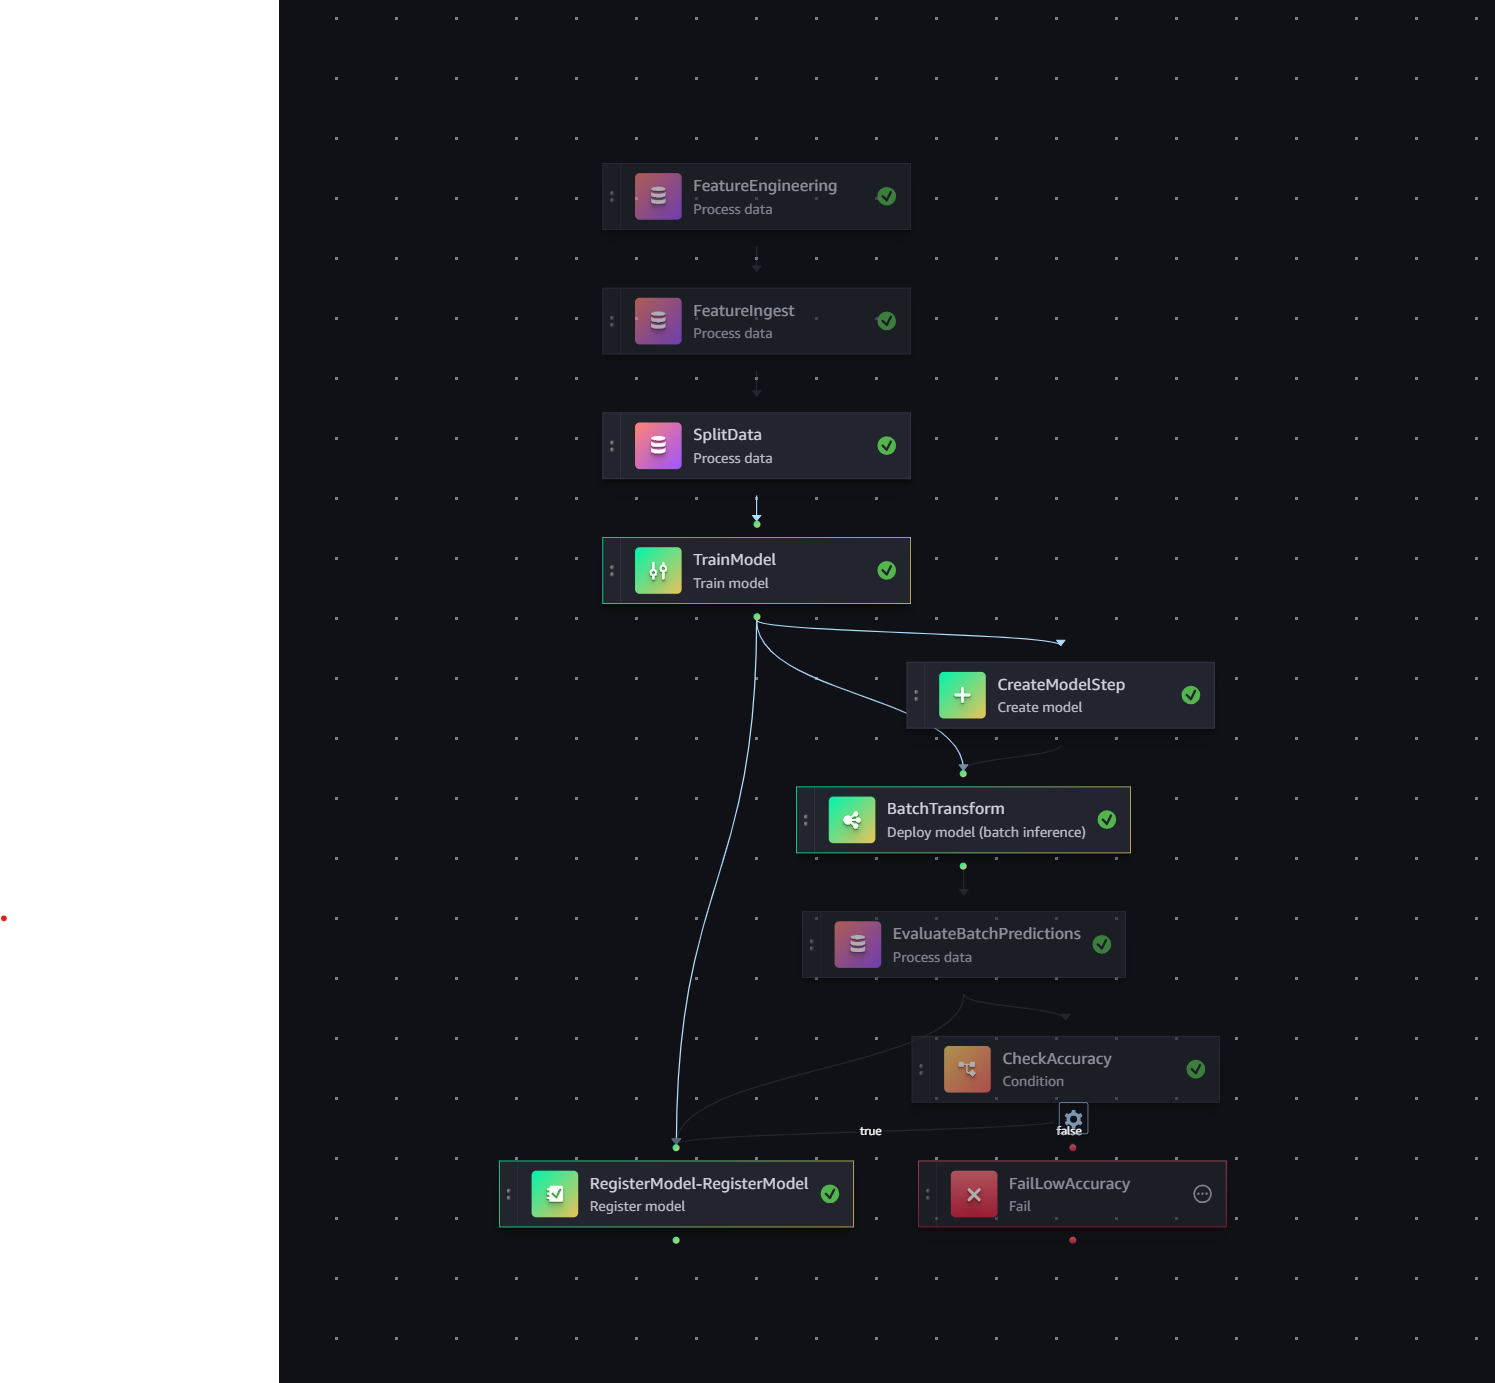

## Pipeline: Accuracy expectation > 99.9%

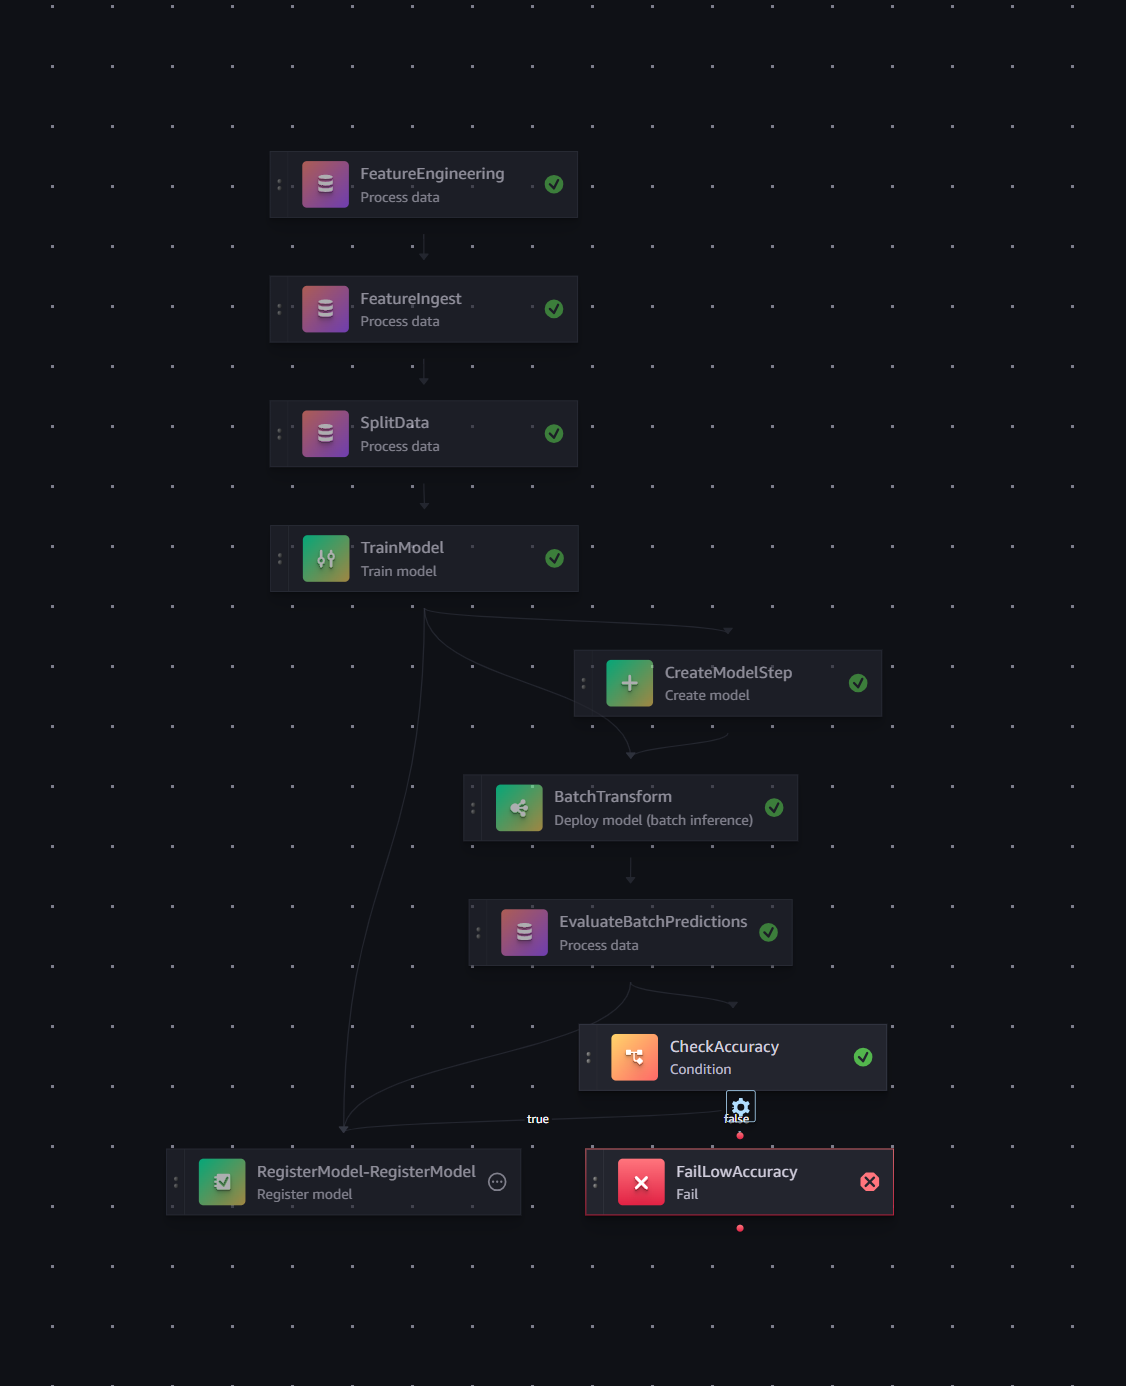



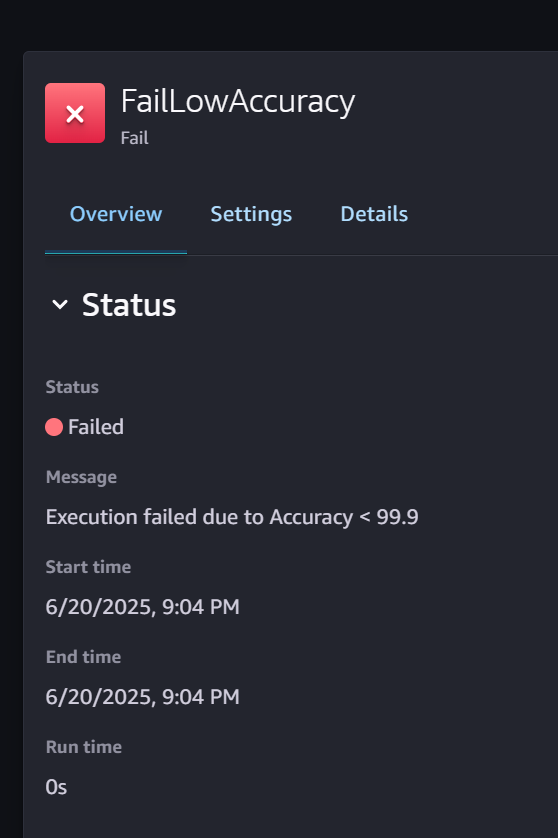